### Prepare data

a bunch of sine waves with different trends, but same frequencies and phases


In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pathlib
import random
import sklearn.linear_model
import torch
import torch.nn as nn
from torch.nn.modules.transformer import MultiheadAttention
from torch.optim.lr_scheduler import LambdaLR

#import utils
#import importlib
#_ = importlib.reload(utils)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", device)
else:
    device = torch.device("cpu")
    print("No GPU -> using CPU:", device)

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'


No GPU -> using CPU: cpu


/home/markus/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [369]:
# prepare sine waves for forecasting

num_datasets=50                     # vary trend (slope) and intercept
num_freq = 3                        # vary frequency
num_features=1                      # stick to univariate data right now
num_points_in_each_dataset=512+96   # fit for TTM 512_96

# for later tuning
hyperparameters = {'output_noise': 0.01, 'variance_weights': 1.0, 'scaling': .2, 'trend': 2}

# shape (150,6) normally distributed around mean 0 for fourier like coefficients
four = torch.distributions.Normal(torch.zeros(num_features+5), hyperparameters['variance_weights']).sample((num_datasets*3,))


# do it in more orderly fashion
ws = torch.zeros(num_datasets, 2)
ws[:,0] = torch.arange(-hyperparameters['trend'], hyperparameters['trend'], 
                       step=2*hyperparameters['trend']/num_datasets, dtype=torch.float)
ws[:,1] = 0.5

#xs = torch.rand(num_datasets, num_points_in_each_dataset, num_features)

xs = torch.meshgrid(torch.arange(num_datasets, dtype=torch.float), 
                    torch.arange(0, np.pi, step=np.pi/num_points_in_each_dataset, dtype=torch.float),
                    torch.arange(num_features, dtype=torch.float))[1]

# concat meshgrid with 1-matrix before multiplying elementwise xs*ws[0](slope) + ws[1](constant) for each of the 50 datasets
xxxs =  torch.einsum('nmf, nf -> nm',
                 torch.cat([xs, torch.ones(num_datasets, num_points_in_each_dataset,1)], 2),
                 ws
                )

# vary frequency
xgrid_ = []
xargs_ = []
for i in range(num_freq):
    xargs_.append(xs * (i+1))
    xgrid_.append(xxxs)

slope = torch.cat(xgrid_,0)
xargs = torch.cat(xargs_,0).squeeze()
'''
# Don't need it now
ys = torch.distributions.Normal(
    torch.einsum('nmf, nf -> nm',
                 torch.cat([xs, torch.ones(num_datasets, num_points_in_each_dataset,1)], 2),
                 ws
                ),
    hyperparameters['output_noise']
).sample()
'''
print(four.shape, torch.stack([torch.sin(xargs * multiplier), torch.cos(xargs * multiplier)]).shape)
#zs = xxxs + torch.sin(xs.squeeze() * 17) * hyperparameters['scaling']
# use 
multiplier = 17
sincos = torch.stack([torch.sin(xargs * multiplier), torch.cos(xargs * multiplier), 
                        torch.sin(xargs * multiplier * 1.5), torch.cos(xargs * multiplier * 1.5),
                        torch.sin(xargs * multiplier * 2), torch.cos(xargs * multiplier * 2)])
signal = torch.einsum('ijk, ji -> jk', sincos, four) * hyperparameters['scaling']
zs = slope + signal #torch.sin(xargs.squeeze() * 17) * hyperparameters['scaling']
#zs = zs.diff()

torch.Size([150, 6]) torch.Size([2, 150, 608])


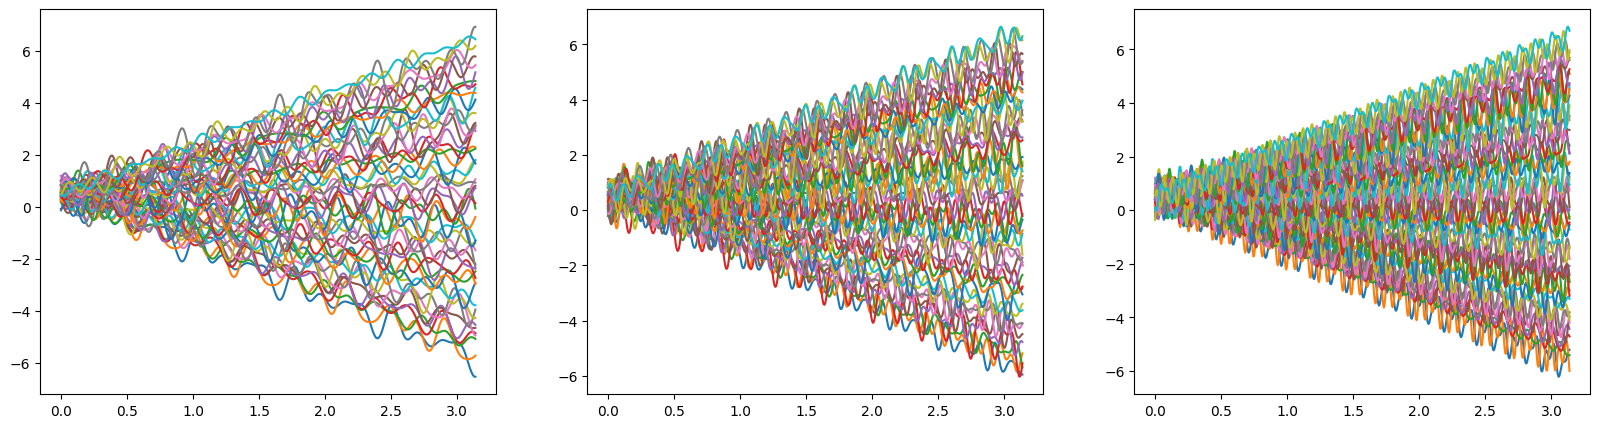

In [370]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
for idx in range(0,50): #range(num_datasets):
    ax[0].plot(xs[idx,:,0].numpy(), zs[idx].numpy())
    ax[1].plot(xs[idx,:,0].numpy(), zs[idx+num_datasets].numpy())
    ax[2].plot(xs[idx,:,0].numpy(), zs[idx+num_datasets*2].numpy()) 

### Try with TTM first

In [371]:
# redefine our loss function 
def trend_loss(targets,outputs,alpha=0.5,device='cpu'):
    sq_error = w_mse2(targets,outputs,device)

    #print('sq_error', sq_error.shape)

    error1=torch.mean(sq_error, dim=-1)

    x1 = derivatives2(targets, device)
    x2 = derivatives2(outputs, device)

    # center by rows first
    _xt1 = x1.squeeze()
    _xt2 = x2.squeeze()

    #print('XT1',_xt1.shape)
    if len(_xt1.shape) == 1:
        _xt1 = torch.reshape(_xt1,(1,_xt1.shape[0]))

    batch_size, lens = _xt1.shape[0:2]
    #print('SQUEEZE reshape', batch_size, lens)

    _xcentered1 = None
    _xcentered2 = None
    if len(_xt1.shape) > 1:
        _xt1 = _xt1.T
        _xt2 = _xt2.T
        _xcentered1 = (_xt1 - _xt1.mean(dim=0)).T
        _xcentered2 = (_xt2 - _xt2.mean(dim=0)).T
    else:
        _xcentered1 = _xt1 - _xt1.mean()
        _xcentered2 = _xt2 - _xt2.mean()
        
    p_corr = torch.nn.functional.cosine_similarity(_xcentered1, _xcentered2, dim=-1)

    w_corr = 1 - p_corr

    dd = torch.norm(targets - outputs, dim=-1)

    d_error = w_corr * dd

    return error1 + alpha * d_error


def w_mse2(targets,outputs,device='cpu'):

    delta=0.00000001
    batch_size, lens = targets.shape[0:2]

    target1= targets[:,1:lens].to(device)
    target2= targets[:,0:lens-1].to(device)
    output1 = outputs[:, 1:lens].to(device)
    output2 = outputs[:, 0:lens - 1].to(device)
    
    sigma_matrix=(target1-target2)*(output1-output2).to(device)

    # paper proposes tanh, but the author's implementation resorts to simple signum
    # sigma=torch.sign(sigma_matrix).to(device)
    sigma=torch.tanh(sigma_matrix).to(device)
    

    newtargets=targets[:,1:lens].to(device)
    newoutputs=outputs[:,1:lens].to(device)

    #print(sigma_matrix)
    
    W1 = 1.01 + torch.abs(newoutputs-newtargets)/(torch.abs(newoutputs+newtargets)+delta)
    W2 = (1.0 - sigma)
    W3 = W1 ** W2
    
   
    #W=(1.01+torch.abs(newoutputs-newtargets)/(torch.abs(newoutputs+newtargets)+delta))**(1.0-sigma).to(device)
    W=torch.abs(newoutputs-newtargets)*(1.0-sigma).to(device)
    print(sigma)

    #w_error=W*torch.abs(newoutputs-newtargets)
    w_error = W

    return w_error

def derivatives2(Input,device='cpu'):

    batch_size,lens =Input.shape[0:2]

    input2 = Input[:,2:lens].to(device)
    input1 = Input[:,0:lens-2].to(device)

    return input2 - input1
    

In [372]:
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
model = TinyTimeMixerForPrediction.from_pretrained("ibm/TTM", cache_dir='/tmp', revision="main")

In [373]:
# I'm not sure whether this is the right way to specify frequency patterns for TTM 
freq = torch.sin(xs[...,0]*17)[0]

# and the public model doesn't support it as you can see
model.decoder.resolution_prefix_tuning, model.backbone.encoder.resolution_prefix_tuning

(False, False)

In [374]:
#zs = zs.diff()
#zhat = model(zs[:,:512,None], freq_token=freq)['prediction_outputs']
zhat = model(zs[:,:512,None])['prediction_outputs']

Text(0.5, 1.0, 'Example forecast with significant phase shift')

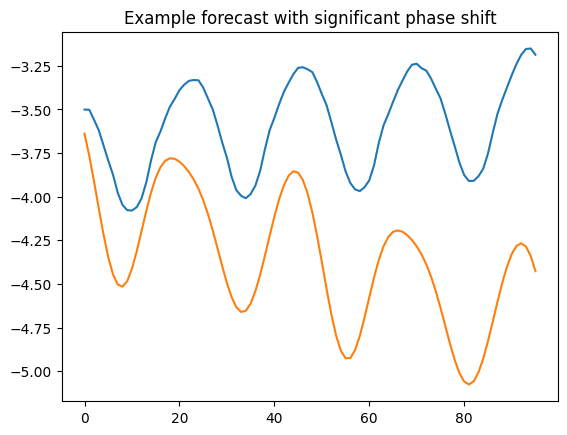

In [375]:
zhat.shape, zs.shape
plt.plot(zhat[104,:].detach().numpy())
plt.plot(zs[104,512:].detach().numpy())
plt.title('Example forecast with significant phase shift')

In [376]:
from cbm_gen.utils.benchmarks.evaluation import tildeq_loss # trend_loss, tildeq_loss
#mse_loss = torch.nn.MSELoss()
loss_trend = trend_loss(zhat.squeeze(), zs[:,512:])
loss_tildeq = tildeq_loss(zhat.squeeze(), zs[:,512:])
loss_mse = torch.norm(zhat.squeeze() - zs[:,512:], dim=1)


tensor([[-3.9298e-04, -2.4861e-04,  1.2167e-04,  ..., -4.8278e-05,
         -9.3126e-05, -7.9772e-06],
        [-3.2693e-04,  1.5781e-04,  5.7225e-04,  ...,  2.6455e-04,
          2.7263e-04,  2.8685e-04],
        [ 6.6502e-04, -3.5516e-05,  1.2741e-04,  ..., -1.4897e-04,
         -1.1127e-04, -2.2000e-04],
        ...,
        [-1.5598e-03,  4.6782e-03,  1.8155e-02,  ...,  3.1945e-02,
          3.1164e-02,  1.0937e-02],
        [ 5.8732e-02,  7.3094e-02,  3.8633e-02,  ...,  1.5695e-03,
         -1.1765e-02, -7.3986e-03],
        [-2.0335e-03,  1.6168e-03, -6.2283e-04,  ...,  2.5227e-04,
         -6.3778e-04,  3.4308e-03]], grad_fn=<TanhBackward0>)


In [377]:
#loss_mse[149], loss_mse[99]

In [378]:
# find the best and worst match according to TildeQ - usually trend and tilde-q agree
bad_idx = loss_tildeq.argmax().detach().item()
good_idx = loss_tildeq.argmin().detach().item()
bad_idx = loss_trend.argmax().detach().item()
good_idx = loss_trend.argmin().detach().item()
bad_idx, good_idx, loss_tildeq.argmax(), loss_tildeq.argmin(), loss_mse.argmax(), loss_mse.argmin()
# surprisingly the plain sine wave is doing less well than a sine wave with a very slight trend

(5, 27, tensor(95), tensor(27), tensor(95), tensor(127))

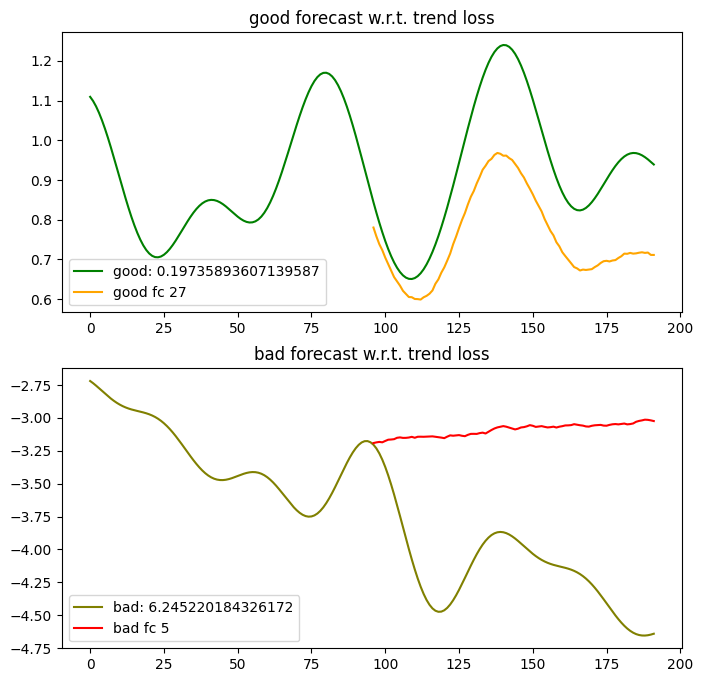

In [379]:
#good_idx = 11
#bad_idx = 75
startat = 512-96
tpl = np.zeros(512).reshape(-1,1)
tpl[:] = np.nan
good = np.vstack((tpl,zhat[good_idx].detach().numpy()))
bad = np.vstack((tpl,zhat[bad_idx].detach().numpy()))

fig, ax = plt.subplots(2,1,figsize=(8,8))
ax[0].set_title('good forecast w.r.t. trend loss')
ax[0].plot(range(512-startat+96), zs[good_idx,startat:].detach().numpy(), label='good: ' + str(loss_trend[good_idx].detach().item()),c='g')
ax[0].plot(range(512-startat+96), good[startat:], label='good fc ' + str(good_idx), c='orange')
ax[1].set_title('bad forecast w.r.t. trend loss')
ax[1].plot(range(512-startat+96), zs[bad_idx,startat:].detach().numpy(), label='bad: ' + str(loss_trend[bad_idx].detach().item()), c='olive')
ax[1].plot(range(512-startat+96), bad[startat:], label='bad fc ' + str(bad_idx), c='red')
ax[0].legend()
ax[1].legend()

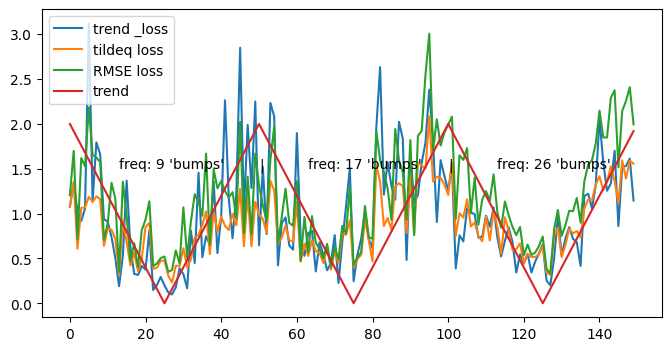

In [380]:
text_y = 1.5
fig,ax = plt.subplots(1,1,figsize=(8,4))
#plt.plot(zhat[bad_idx].detach().numpy())
#plt.plot(zs[bad_idx,512:].detach().numpy())
ax.plot(loss_trend.clip(0,30).detach().numpy()/2, label='trend _loss')
ax.plot(loss_tildeq.detach().numpy(), label='tildeq loss')
ax.plot(loss_mse.detach().numpy()/5, label='RMSE loss')
#ax.scatter([50,100], [0.5,0.5], s=30, c='red', marker='|')
ax.plot(torch.cat([abs(ws), abs(ws), abs(ws)]).detach().numpy()[:,0], label='trend')
ax.text(13,text_y,'freq: 9 \'bumps\'')
ax.text(50,text_y,'|')
ax.text(63,text_y,'freq: 17 \'bumps\'')
ax.text(100,text_y,'|')
ax.text(113,text_y,'freq: 26 \'bumps\'')
ax.legend()

### Differencing to eliminate the trend - bringing back the I or ARIMA

We also scale up by 10.



In [396]:

zs_diff = torch.cat([zs, zs[:,-1:]], dim=-1)
zs_diff = zs_diff.diff(dim=-1)*10

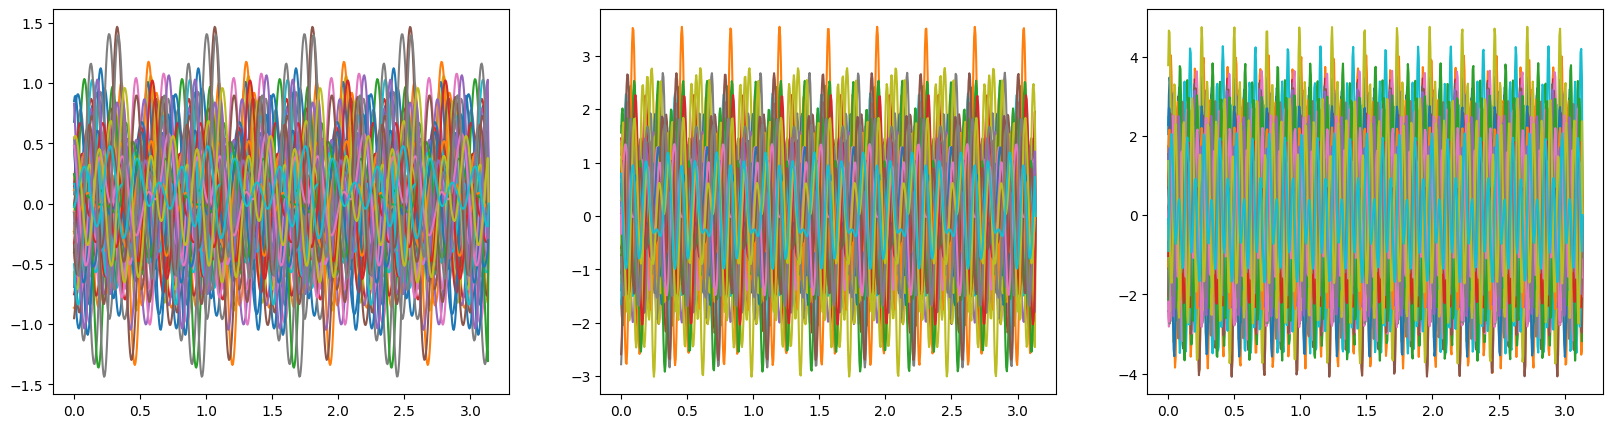

In [397]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
for idx in range(0,50): #range(num_datasets):
    ax[0].plot(xs[idx,:,0].numpy(), zs_diff[idx].numpy())
    ax[1].plot(xs[idx,:,0].numpy(), zs_diff[idx+num_datasets].numpy())
    ax[2].plot(xs[idx,:,0].numpy(), zs_diff[idx+num_datasets*2].numpy()) 

In [398]:
zdiff_hat = model(zs_diff[:,:512,None])['prediction_outputs']

In [399]:
lossd_trend = trend_loss2(zdiff_hat.squeeze(), zs_diff[:,512:])
lossd_tildeq = tildeq_loss(zdiff_hat.squeeze(), zs_diff[:,512:])
lossd_mse = torch.norm(zdiff_hat.squeeze() - zs_diff[:,512:], dim=1)



tensor([[ 6.8350e-04,  1.0509e-04, -6.5013e-05,  ...,  5.6766e-03,
          7.1516e-03,  1.0723e-03],
        [ 9.1153e-04,  1.9322e-03,  2.6711e-03,  ...,  4.1686e-04,
          1.9877e-04, -3.3729e-03],
        [ 8.3034e-04,  1.7186e-04,  1.9858e-04,  ...,  5.9631e-04,
          5.0004e-04, -1.8803e-03],
        ...,
        [ 4.2448e-01,  2.0577e-01, -5.2599e-03,  ..., -5.1116e-02,
          9.3553e-02,  2.5442e-01],
        [ 3.6171e-02,  2.1614e-01,  6.3565e-01,  ...,  7.3415e-01,
          7.9075e-01, -9.8283e-01],
        [ 2.8641e-02,  8.1215e-02,  1.2370e-01,  ...,  2.9915e-01,
          1.8045e-01, -3.9668e-01]], grad_fn=<TanhBackward0>)


In [404]:
# find the best and worst match according to TildeQ - usually trend and tilde-q agree
badd_idx = lossd_tildeq.argmax().detach().item()
goodd_idx = lossd_tildeq.argmin().detach().item()
badd_idx = lossd_trend.argmax().detach().item()
goodd_idx = lossd_trend.argmin().detach().item()
badd_idx, goodd_idx, lossd_tildeq.argmax(), lossd_tildeq.argmin(), lossd_mse.argmax(), lossd_mse.argmin()

(88, 27, tensor(101), tensor(41), tensor(88), tensor(41))

#### Results

It still doesn't like all frequency mixes

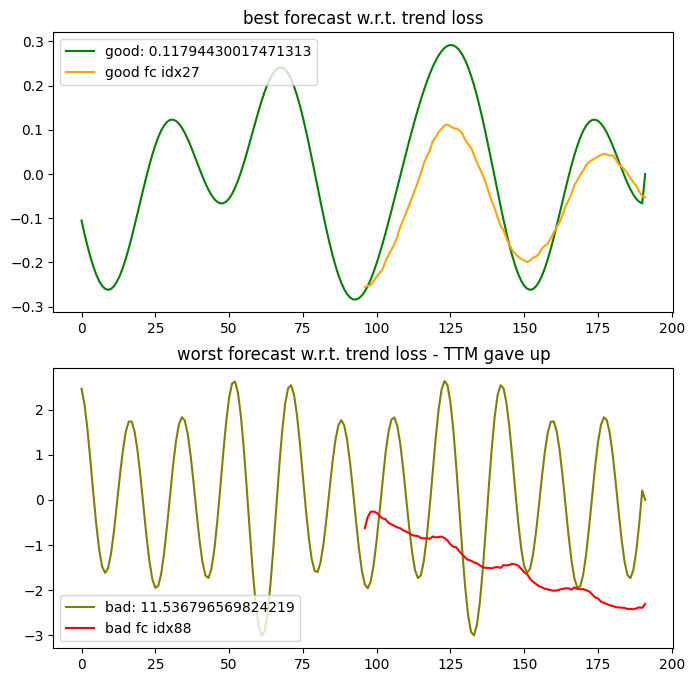

In [418]:
startat = 512-96
tpl = np.zeros(512).reshape(-1,1)
tpl[:] = np.nan
good = np.vstack((tpl,zdiff_hat[goodd_idx].detach().numpy()))
bad = np.vstack((tpl,zdiff_hat[badd_idx].detach().numpy()))

fig, ax = plt.subplots(2,1,figsize=(8,8))
ax[0].set_title('best forecast w.r.t. trend loss')
ax[0].plot(range(512-startat+96), zs_diff[goodd_idx,startat:].detach().numpy(), label='good: ' + str(lossd_trend[goodd_idx].detach().item()),c='g')
ax[0].plot(range(512-startat+96), good[startat:], label='good fc idx' + str(goodd_idx), c='orange')
ax[1].set_title('worst forecast w.r.t. trend loss - TTM gave up')
ax[1].plot(range(512-startat+96), zs_diff[badd_idx,startat:].detach().numpy(), label='bad: ' + str(lossd_trend[badd_idx].detach().item()), c='olive')
ax[1].plot(range(512-startat+96), bad[startat:], label='bad fc idx' + str(badd_idx), c='red')
ax[0].legend()
ax[1].legend()

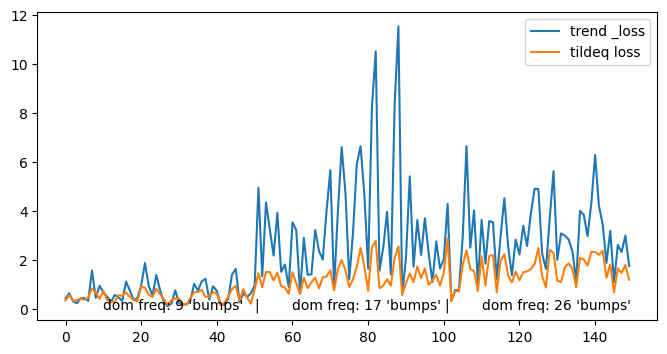

In [406]:
text_y = 0.0
fig,ax = plt.subplots(1,1,figsize=(8,4))

ax.plot(lossd_trend.detach().numpy(), label='trend _loss')
ax.plot(lossd_tildeq.detach().numpy(), label='tildeq loss')
#ax.plot(lossd_mse.detach().numpy()/3, label='RMSE loss')
#ax.scatter([50,100], [0.5,0.5], s=30, c='red', marker='|')
#ax.plot(torch.cat([abs(ws), abs(ws), abs(ws)]).detach().numpy()[:,0], label='trend')
ax.text(10,text_y,'dom freq: 9 \'bumps\'')
ax.text(50,text_y,'|')
ax.text(60,text_y,'dom freq: 17 \'bumps\'')
ax.text(100,text_y,'|')
ax.text(110,text_y,'dom freq: 26 \'bumps\'')
ax.legend()

In [413]:
lossd_trend[83]

tensor(1.5757, grad_fn=<SelectBackward0>)

In [134]:
'''
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(range(96), zs[0,512:].detach().numpy(), label='Example Forecast0', c='black')
ax.plot(range(96), zhat[0].detach().numpy(), label='Example GroundTruth0', c='black')

for dataset_index in range(10):
    ax.plot(range(96), zhat[dataset_index].squeeze().detach().numpy() - zs[dataset_index,512:].detach().numpy(),
             label='loss[' + str(dataset_index) + ']  ' + str(loss_trend[dataset_index].detach().item()))
             
ax.plot(range(96), zhat[33].squeeze().detach().numpy() - zs[33,512:].detach().numpy(),
             label='loss[' + str(33) + ']  ' + str(loss_trend[33].detach().item()))
ax.legend()
'''


"\nfig, ax = plt.subplots(1,1,figsize=(10,5))\nax.plot(range(96), zs[0,512:].detach().numpy(), label='Example Forecast0', c='black')\nax.plot(range(96), zhat[0].detach().numpy(), label='Example GroundTruth0', c='black')\n\nfor dataset_index in range(10):\n    ax.plot(range(96), zhat[dataset_index].squeeze().detach().numpy() - zs[dataset_index,512:].detach().numpy(),\n             label='loss[' + str(dataset_index) + ']  ' + str(loss_trend[dataset_index].detach().item()))\n             \nax.plot(range(96), zhat[33].squeeze().detach().numpy() - zs[33,512:].detach().numpy(),\n             label='loss[' + str(33) + ']  ' + str(loss_trend[33].detach().item()))\nax.legend()\n"